In [2]:
# Cell 1: Imports, paths, and WhiteboxTools initialization
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path
from shapely.geometry import Point, LineString
import whitebox

# --- Paths ---
dem_path = Path("../data/kali44N.tif")
pourpoint_path = Path("../data/kali_pourpoint.shp")
results_dir = Path("../results")
figures_dir = results_dir / "figures"
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

# --- WhiteboxTools setup ---
wbt = whitebox.WhiteboxTools()
wbt.set_verbose_mode(True)
wbt.set_working_dir(str(results_dir.resolve()))

print("Setup complete.")
print("DEM path:", dem_path.resolve())
print("Pour point path:", pourpoint_path.resolve())

Setup complete.
DEM path: D:\kaligandaki\data\kali44N.tif
Pour point path: D:\kaligandaki\data\kali_pourpoint.shp


In [3]:
# Cell 2: Validate DEM and pour point (CRS match, extent, NoData, elevation range)
with rasterio.open(dem_path) as src:
    dem_crs = src.crs
    dem_res = src.res
    dem_bounds = src.bounds
    dem_nodata = src.nodata
    dem_band = src.read(1, masked=True)

pourpoint = gpd.read_file(pourpoint_path)

print("DEM CRS:", dem_crs, "| Pour point CRS:", pourpoint.crs)
print("CRS match:", dem_crs == pourpoint.crs)
print("DEM resolution:", dem_res)
print("DEM elevation range:", dem_band.min(), "-", dem_band.max())

px, py = pourpoint.geometry.iloc[0].x, pourpoint.geometry.iloc[0].y
inside = (dem_bounds.left <= px <= dem_bounds.right) and (dem_bounds.bottom <= py <= dem_bounds.top)
print("Pour point inside DEM extent:", inside)

dem_prepared = str(dem_path.resolve())

DEM CRS: EPSG:32644 | Pour point CRS: EPSG:32644
CRS match: True
DEM resolution: (29.512736202782968, 29.51273620278292)
DEM elevation range: 67 - 8141
Pour point inside DEM extent: True


In [4]:
# Cell 3: Fill DEM depressions (removes artificial sinks that break flow routing)
dem_filled = str((results_dir / "dem_filled.tif").resolve())
wbt.fill_depressions(dem=dem_prepared, output=dem_filled)

with rasterio.open(dem_filled) as src:
    filled_band = src.read(1, masked=True)
    print("Filled DEM elevation range:", filled_band.min(), "-", filled_band.max())

.\whitebox_tools.exe --run="FillDepressions" --wd="D:\kaligandaki\results" --dem='D:\kaligandaki\data\kali44N.tif' --output='D:\kaligandaki\results\dem_filled.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding pit cells: 5%
Finding pit cells: 10%
Finding pit cells: 15%
Finding pit cells: 20%
Finding pit cells: 25%
Finding pit cells: 30%
Finding pit cells: 35%
Finding pit cells: 40%
Finding pit cells: 45%
Finding pit cells: 50%
Finding pit cells: 55%
Finding pit cells: 60%
Finding pit cells: 65%
Finding pit cells: 70%
Finding pit cells: 75%
Finding pit cells: 80%
Finding pit cells: 85%
Finding pit cells: 90%
Finding pit cells: 95%
Finding pit cells: 100%
Filling depressions: 0%
Filling depressions: 1%
Filling depressions: 2%
Filling depressions: 3%
Filling depressions: 4%
Filling depressions: 5%
Filling depressions:

In [5]:
# Cell 4: Compute D8 flow direction from filled DEM
flow_direction = str((results_dir / "flow_direction.tif").resolve())
wbt.d8_pointer(dem=dem_filled, output=flow_direction)

with rasterio.open(flow_direction) as src:
    fdir_band = src.read(1, masked=True)
    print("Flow direction value range:", fdir_band.min(), "-", fdir_band.max())

.\whitebox_tools.exe --run="D8Pointer" --wd="D:\kaligandaki\results" --dem='D:\kaligandaki\results\dem_filled.tif' --output='D:\kaligandaki\results\flow_direction.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%
Progress: 42%
Progress: 43%
Progress: 44%
Progress: 45%
Progress

In [6]:
# Cell 5: Compute D8 flow accumulation (cell counts) from filled DEM
flow_accumulation = str((results_dir / "flow_accumulation.tif").resolve())
wbt.d8_flow_accumulation(i=dem_filled, output=flow_accumulation, out_type="cells")

with rasterio.open(flow_accumulation) as src:
    facc_band = src.read(1, masked=True)
    facc_res = src.res

cell_area_km2 = (facc_res[0] * facc_res[1]) / 1_000_000
print("Cell area (km²):", cell_area_km2)
print("Max contributing area in DEM (km²):", facc_band.max() * cell_area_km2)

.\whitebox_tools.exe --run="D8FlowAccumulation" --wd="D:\kaligandaki\results" --input='D:\kaligandaki\results\dem_filled.tif' --output='D:\kaligandaki\results\flow_accumulation.tif' --out_type=cells -v --compress_rasters=False

*********************************
* Welcome to D8FlowAccumulation *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************
Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
Flow directions: 25%
Flow directions: 26%
Flow directions: 27%
Flow dir

In [7]:
# Cell 6: Stream initiation threshold — literature-informed choice (1 km²), validated against
# slope-break analysis of the contributing-area distribution within the watershed
stream_threshold_km2 = 1.0
stream_threshold_cells = int(round(stream_threshold_km2 / cell_area_km2))
print(f"Stream threshold: {stream_threshold_km2} km² = {stream_threshold_cells} cells")
print("Rationale: literature-typical channel initiation threshold for steep, ~30m-resolution")
print("mountainous terrain (0.5-1 km²); automated slope-break detection was inconclusive")
print("(bimodal, noise-affected), so this value was chosen deliberately and is documented as such.")

Stream threshold: 1.0 km² = 1148 cells
Rationale: literature-typical channel initiation threshold for steep, ~30m-resolution
mountainous terrain (0.5-1 km²); automated slope-break detection was inconclusive
(bimodal, noise-affected), so this value was chosen deliberately and is documented as such.


In [8]:
# Cell 7: Threshold flow accumulation to a stream raster, snap pour point to it, delineate watershed
streams_raster = str((results_dir / "streams_binary.tif").resolve())

with rasterio.open(flow_accumulation) as src:
    facc_full = src.read(1)
    profile = src.profile

stream_mask = np.where(facc_full >= stream_threshold_cells, 1, profile["nodata"]).astype(profile["dtype"])
with rasterio.open(streams_raster, "w", **profile) as dst:
    dst.write(stream_mask, 1)

pourpoint_snapped = str((results_dir / "pourpoint_snapped.shp").resolve())
wbt.jenson_snap_pour_points(
    pour_pts=str(pourpoint_path.resolve()),
    streams=streams_raster,
    output=pourpoint_snapped,
    snap_dist=200,
)

snapped_gdf = gpd.read_file(pourpoint_snapped)
snap_x, snap_y = snapped_gdf.geometry.iloc[0].x, snapped_gdf.geometry.iloc[0].y

with rasterio.open(flow_accumulation) as src:
    row_chk, col_chk = src.index(snap_x, snap_y)
    facc_at_snap = src.read(1)[row_chk, col_chk]

print(f"Snapped pour point: ({snap_x:.2f}, {snap_y:.2f})")
print(f"Contributing area at snapped point: {facc_at_snap * cell_area_km2:.1f} km²  (expect ~11,870 km²)")

.\whitebox_tools.exe --run="JensonSnapPourPoints" --wd="D:\kaligandaki\results" --pour_pts='D:\kaligandaki\data\kali_pourpoint.shp' --streams='D:\kaligandaki\results\streams_binary.tif' --output='D:\kaligandaki\results\pourpoint_snapped.shp' --snap_dist='200' -v --compress_rasters=False

***********************************
* Welcome to JensonSnapPourPoints *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************
Reading data...
Progress: 0%
Saving data...
Output file written
Elapsed Time (excluding I/O): 0.0s
Snapped pour point: (837393.36, 3073520.21)
Contributing area at snapped point: 11870.6 km²  (expect ~11,870 km²)


In [9]:
# Cell 8: Delineate watershed from the correctly-snapped pour point
watershed_raster = str((results_dir / "watershed.tif").resolve())
wbt.watershed(d8_pntr=flow_direction, pour_pts=pourpoint_snapped, output=watershed_raster)

with rasterio.open(watershed_raster) as src:
    ws_data = src.read(1)
    ws_nodata = src.nodata
    ws_res = src.res

valid_ws_mask_full = (ws_data > 0) & (ws_data != ws_nodata)
ws_area_km2 = valid_ws_mask_full.sum() * (ws_res[0]*ws_res[1]) / 1_000_000
print(f"Watershed area: {ws_area_km2:.2f} km²  (expect ~11,870 km²)")

.\whitebox_tools.exe --run="Watershed" --wd="D:\kaligandaki\results" --d8_pntr='D:\kaligandaki\results\flow_direction.tif' --pour_pts='D:\kaligandaki\results\pourpoint_snapped.shp' --output='D:\kaligandaki\results\watershed.tif' -v --compress_rasters=False

****************************
* Welcome to Watershed     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Locating pour points: 0%
Initializing: 1%
Initializing: 2%
Initializing: 3%
Initializing: 4%
Initializing: 5%
Initializing: 6%
Initializing: 7%
Initializing: 8%
Initializing: 9%
Initializing: 10%
Initializing: 11%
Initializing: 12%
Initializing: 13%
Initializing: 14%
Initializing: 15%
Initializing: 16%
Initializing: 17%
Initializing: 18%
Initializing: 19%
Initializing: 20%
Initializing: 21%
Initializing: 22%
Initializing: 23%
Initializing: 24%
Initializing: 25%
Initializing: 26%
Initializing: 27%
Initializing: 28%
Initializing: 29%
Initializing: 30%
Initializing: 31%
Initial

In [10]:
# Cell 9: Extract stream network raster (masked to watershed), vectorize, fix CRS (WBT drops it)
stream_network_raster = str((results_dir / "stream_network.tif").resolve())
stream_data = np.where((facc_full >= stream_threshold_cells) & valid_ws_mask_full, 1, profile["nodata"]).astype(profile["dtype"])
with rasterio.open(stream_network_raster, "w", **profile) as dst:
    dst.write(stream_data, 1)

stream_vector = str((results_dir / "stream_network.shp").resolve())
wbt.raster_streams_to_vector(streams=stream_network_raster, d8_pntr=flow_direction, output=stream_vector)

streams_gdf = gpd.read_file(stream_vector)
streams_gdf = streams_gdf.set_crs("EPSG:32644", allow_override=True)  # WBT drops CRS — must restore

river_network_gpkg = str((results_dir / "river_network.gpkg").resolve())
streams_gdf.to_file(river_network_gpkg, driver="GPKG")

print("Stream segments:", len(streams_gdf))
print("Total vectorized length (km):", streams_gdf.geometry.length.sum() / 1000)

.\whitebox_tools.exe --run="RasterStreamsToVector" --wd="D:\kaligandaki\results" --streams='D:\kaligandaki\results\stream_network.tif' --d8_pntr='D:\kaligandaki\results\flow_direction.tif' --output='D:\kaligandaki\results\stream_network.shp' -v --compress_rasters=False

************************************
* Welcome to RasterStreamsToVector *
* Powered by WhiteboxTools         *
* www.whiteboxgeo.com              *
************************************
Reading pointer data...
Reading streams data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Pr

In [11]:
# Cell 10: Build the river network as a graph (nodes=endpoints, edges=segments); confirm tree structure
G = nx.Graph()
coord_precision = 2

def round_coord(pt, precision=coord_precision):
    return (round(pt[0], precision), round(pt[1], precision))

for idx, row in streams_gdf.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue
    coords = list(geom.coords)
    start = round_coord(coords[0])
    end = round_coord(coords[-1])
    G.add_edge(start, end, length=geom.length, fid=row["FID"], geometry=geom)

print("Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())
print("Is connected:", nx.is_connected(G))

# Identify outlet node: leaf node closest to the snapped pour point
degrees = dict(G.degree())
leaf_nodes = [n for n, d in degrees.items() if d == 1]
outlet_node = min(leaf_nodes, key=lambda n: (n[0]-snap_x)**2 + (n[1]-snap_y)**2)
print("Outlet node:", outlet_node)

Nodes: 6302 | Edges: 6301
Is connected: True
Outlet node: (837393.36, 3073490.7)


In [12]:
# Cell 11: Compute cumulative distance from outlet for every node, and build each edge's
# ancestor chain (list of edges from outlet to that edge) — needed for graph-walking sampling
# and later for the multi-scale downstream search.
node_cum_dist = {outlet_node: 0.0}
visited = {outlet_node}
queue = [outlet_node]
while queue:
    node = queue.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited:
            continue
        node_cum_dist[neighbor] = node_cum_dist[node] + G.edges[node, neighbor]["length"]
        visited.add(neighbor)
        queue.append(neighbor)

edge_near_far = {}
for u, v, data in G.edges(data=True):
    fid = data["fid"]
    near, far = (u, v) if node_cum_dist[u] < node_cum_dist[v] else (v, u)
    edge_near_far[fid] = (near, far)
edge_range = {fid: (node_cum_dist[near], node_cum_dist[far]) for fid, (near, far) in edge_near_far.items()}

edge_ancestor_chain = {}
visited_nodes = {outlet_node}
stack = [(outlet_node, [])]
while stack:
    node, chain = stack.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited_nodes:
            continue
        fid = G.edges[node, neighbor]["fid"]
        near, far = edge_near_far[fid]
        if near != node:
            continue
        new_chain = chain + [fid]
        edge_ancestor_chain[fid] = new_chain
        visited_nodes.add(neighbor)
        stack.append((neighbor, new_chain))

print("Nodes with cumulative distance:", len(node_cum_dist))
print("Edges with ancestor chains:", len(edge_ancestor_chain), "/", G.number_of_edges())

Nodes with cumulative distance: 6302
Edges with ancestor chains: 6301 / 6301


In [13]:
# Cell 12: Sample points every 500m along the network, using cumulative graph distance
# so spacing stays continuous across confluences (not reset per segment).
sample_spacing_m = 500
river_points = []
point_id = 0
visited2 = {outlet_node}
stack = [(outlet_node, 0.0)]

while stack:
    node, cum_dist = stack.pop()
    for neighbor in G.neighbors(node):
        if neighbor in visited2:
            continue
        edge_data = G.edges[node, neighbor]
        geom = edge_data["geometry"]
        length = edge_data["length"]

        coords = list(geom.coords)
        start_pt = round_coord(coords[0])
        if start_pt != node:
            geom = LineString(coords[::-1])

        dist_start, dist_end = cum_dist, cum_dist + length
        k_start = 0 if dist_start == 0 else int(np.ceil(dist_start / sample_spacing_m))
        k_end = int(np.floor(dist_end / sample_spacing_m))

        for k in range(k_start, k_end + 1):
            global_dist = k * sample_spacing_m
            local_dist = global_dist - dist_start
            if 0 <= local_dist <= length:
                pt = geom.interpolate(local_dist)
                river_points.append({"point_id": point_id, "edge_fid": edge_data["fid"],
                                      "cum_dist_from_outlet_m": global_dist, "geometry": pt})
                point_id += 1

        visited2.add(neighbor)
        stack.append((neighbor, dist_end))

river_points_gdf = gpd.GeoDataFrame(river_points, crs="EPSG:32644")
print("Total river points sampled:", len(river_points_gdf))

Total river points sampled: 16295


In [14]:
# Cell 13: Extract elevation (from filled DEM) and contributing area (discharge proxy,
# from flow accumulation) at every sampled river point.
with rasterio.open(dem_filled) as src:
    dem_arr = src.read(1)
    dem_transform = src.transform

with rasterio.open(flow_accumulation) as src:
    facc_arr = src.read(1)
    facc_transform = src.transform

elevations, contrib_areas = [], []
for geom in river_points_gdf.geometry:
    row_e, col_e = rasterio.transform.rowcol(dem_transform, geom.x, geom.y)
    elevations.append(dem_arr[row_e, col_e])
    row_f, col_f = rasterio.transform.rowcol(facc_transform, geom.x, geom.y)
    contrib_areas.append(facc_arr[row_f, col_f] * cell_area_km2)

river_points_gdf["elevation_m"] = elevations
river_points_gdf["contrib_area_km2"] = contrib_areas

river_points_gpkg = str((results_dir / "river_points.gpkg").resolve())
river_points_gdf.to_file(river_points_gpkg, driver="GPKG")

print("Elevation range:", river_points_gdf["elevation_m"].min(), "-", river_points_gdf["elevation_m"].max())
print("Contributing area range (km²):", river_points_gdf["contrib_area_km2"].min(), "-", river_points_gdf["contrib_area_km2"].max())

Elevation range: 190.00167999999996 - 6570.0
Contributing area range (km²): 0.9999099 - 11870.601


In [15]:
# Cell 14: For every "major" reach point (contributing area >= 100 km²), search downstream
# at every 500m increment up to 10km, keeping whichever span gives the best route-length ratio.
# This is the core methodology fix: catches loops/bends at any scale, not just fixed 500m reaches.
edge_points = {fid: g.sort_values("cum_dist_from_outlet_m").reset_index(drop=True)
               for fid, g in river_points_gdf.groupby("edge_fid")}

def find_ancestor_point(edge_fid, target_dist):
    if target_dist < 0:
        return None
    for fid in edge_ancestor_chain.get(edge_fid, []):
        lo, hi = edge_range[fid]
        if lo - 1e-6 <= target_dist <= hi + 1e-6:
            pts = edge_points.get(fid)
            if pts is None:
                return None
            match = pts[np.isclose(pts["cum_dist_from_outlet_m"], target_dist, atol=1.0)]
            return match.iloc[0] if not match.empty else None
    return None

span_options_m = list(range(500, 10001, 500))
major_points = river_points_gdf[river_points_gdf["contrib_area_km2"] >= 100].copy()

results = []
for _, p in major_points.iterrows():
    best = None
    for span in span_options_m:
        target_dist = p["cum_dist_from_outlet_m"] - span
        anc = find_ancestor_point(p["edge_fid"], target_dist)
        if anc is None:
            continue
        dz = p["elevation_m"] - anc["elevation_m"]
        if dz <= 0:
            continue
        euclid = np.hypot(p.geometry.x - anc.geometry.x, p.geometry.y - anc.geometry.y)
        if euclid <= 0:
            continue
        ratio = span / euclid
        if best is None or ratio > best["route_length_ratio"]:
            best = {
                "point_id": p["point_id"],
                "upstream_x": p.geometry.x, "upstream_y": p.geometry.y,
                "downstream_x": anc.geometry.x, "downstream_y": anc.geometry.y,
                "upstream_elevation_m": p["elevation_m"], "downstream_elevation_m": anc["elevation_m"],
                "delta_z_m": dz, "river_distance_m": span, "euclidean_distance_m": euclid,
                "river_gradient_pct": 100*dz/span, "euclidean_gradient_pct": 100*dz/euclid,
                "route_length_ratio": ratio, "contrib_area_km2": p["contrib_area_km2"],
            }
    if best is not None:
        results.append(best)

multiscale_df = pd.DataFrame(results)
print("Points searched:", len(major_points), "| Valid results:", len(multiscale_df))

Points searched: 2150 | Valid results: 2149


In [16]:
# Cell 15: Screen candidates (ratio>=2.0, ΔZ>=30m, euclidean_gradient>=3%), then deduplicate
# spatially (radius=1500m) since the same physical bend is often re-detected from multiple
# nearby starting points at different span lengths.
mask = (multiscale_df["route_length_ratio"] >= 2.0) & \
       (multiscale_df["delta_z_m"] >= 30) & \
       (multiscale_df["euclidean_gradient_pct"] >= 3)
final_candidates = multiscale_df[mask].sort_values("route_length_ratio", ascending=False).reset_index(drop=True)

dedup_radius_m = 1500
kept_indices, kept_coords = [], []
for idx, row in final_candidates.iterrows():
    pt = (row["upstream_x"], row["upstream_y"])
    if not any(np.hypot(pt[0]-kx, pt[1]-ky) < dedup_radius_m for kx, ky in kept_coords):
        kept_indices.append(idx)
        kept_coords.append(pt)

deduped_candidates = final_candidates.loc[kept_indices].reset_index(drop=True)
deduped_candidates["reach_id"] = range(len(deduped_candidates))

print("Candidates before dedup:", len(final_candidates), "| After dedup:", len(deduped_candidates))
print(deduped_candidates[["reach_id", "delta_z_m", "river_distance_m", "euclidean_distance_m",
                            "route_length_ratio", "euclidean_gradient_pct", "contrib_area_km2"]])

Candidates before dedup: 35 | After dedup: 12
    reach_id  delta_z_m  river_distance_m  euclidean_distance_m  \
0          0   44.99832              3500           1050.249503   
1          1   86.99580              6500           2224.146695   
2          2   84.98572              7000           2536.834027   
3          3   41.99118              2000            766.345631   
4          4  195.00000              2500            969.965300   
5          5   32.99958              2500           1010.091408   
6          6  165.98446              9500           3904.486474   
7          7  145.99706              9500           4009.986789   
8          8  466.96934              4500           2009.210803   
9          9   70.98782              4000           1788.984314   
10        10   33.99958              2000            914.119396   
11        11   84.00168              5500           2663.460763   

    route_length_ratio  euclidean_gradient_pct  contrib_area_km2  
0             3

In [17]:
# Cell 16: Export final candidate reaches (CSV + GeoPackage) and supporting river network data
export_cols = ["reach_id", "downstream_x", "downstream_y", "upstream_x", "upstream_y",
               "downstream_elevation_m", "upstream_elevation_m", "delta_z_m",
               "river_distance_m", "euclidean_distance_m", "route_length_ratio",
               "river_gradient_pct", "euclidean_gradient_pct", "contrib_area_km2"]

deduped_candidates[export_cols].to_csv(results_dir / "candidate_reaches.csv", index=False)

candidates_gdf = gpd.GeoDataFrame(
    deduped_candidates[export_cols],
    geometry=gpd.points_from_xy(deduped_candidates["upstream_x"], deduped_candidates["upstream_y"]),
    crs="EPSG:32644"
)
candidates_gdf.to_file(results_dir / "candidate_reaches.gpkg", driver="GPKG")

print(f"Exported {len(deduped_candidates)} final candidate sites.")
print("Files: candidate_reaches.csv, candidate_reaches.gpkg, river_network.gpkg, river_points.gpkg")

Exported 12 final candidate sites.
Files: candidate_reaches.csv, candidate_reaches.gpkg, river_network.gpkg, river_points.gpkg


In [18]:
# Cell 17: Build the shared watershed-clipped window (bounding box + valid-data mask) used
# by every map below, so the rectangular DEM extent never appears in any figure.
with rasterio.open(watershed_raster) as src:
    ws_full = src.read(1)
    ws_nodata_val = src.nodata
    ws_transform = src.transform

valid_mask_full = (ws_full > 0) & (ws_full != ws_nodata_val)
rows_v, cols_v = np.where(valid_mask_full)
buffer_cells = 20
row_min = max(rows_v.min() - buffer_cells, 0)
row_max = min(rows_v.max() + buffer_cells, ws_full.shape[0] - 1)
col_min = max(cols_v.min() - buffer_cells, 0)
col_max = min(cols_v.max() + buffer_cells, ws_full.shape[1] - 1)

x_min, y_max = ws_transform * (col_min, row_min)
x_max, y_min = ws_transform * (col_max + 1, row_max + 1)

valid_mask_crop = valid_mask_full[row_min:row_max+1, col_min:col_max+1]

with rasterio.open(dem_filled) as src:
    dem_full = src.read(1)
dem_crop = dem_full[row_min:row_max+1, col_min:col_max+1]
dem_masked = np.ma.masked_where(~valid_mask_crop, dem_crop)

print("Clipped map extent:", (x_min, x_max, y_min, y_max))

Clipped map extent: (np.float64(683322.1170994539), np.float64(839739.6189742037), np.float64(3069934.416767042), np.float64(3248722.572683501))


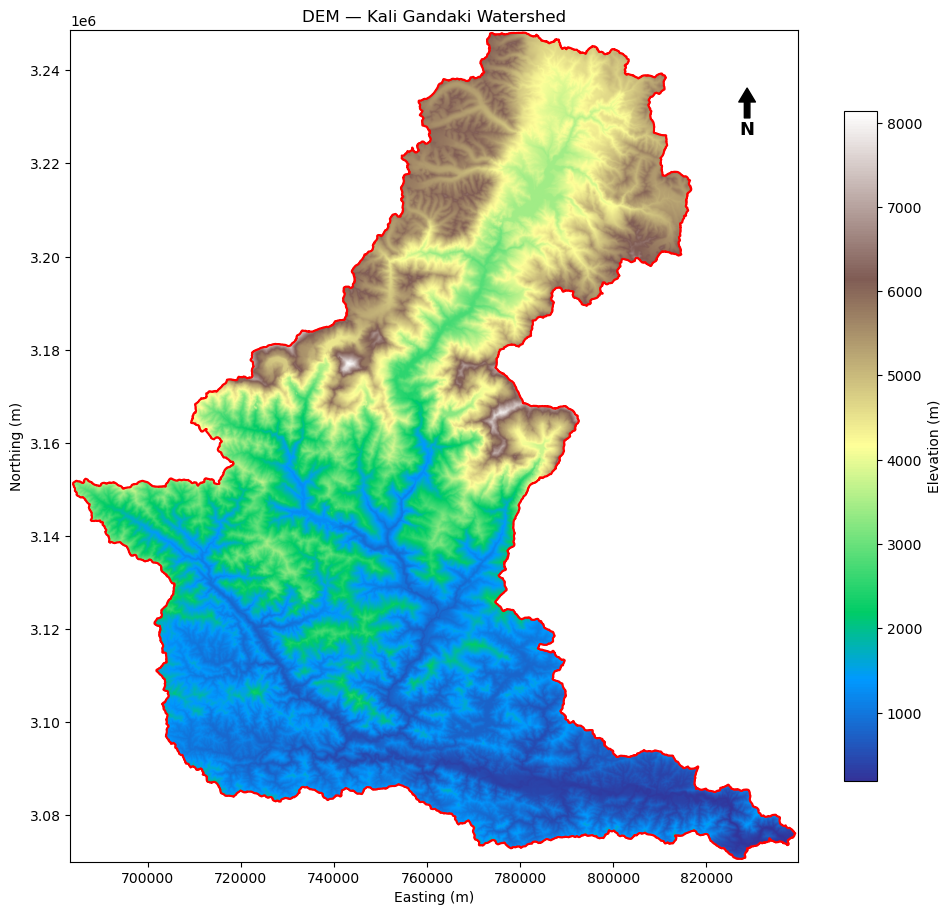

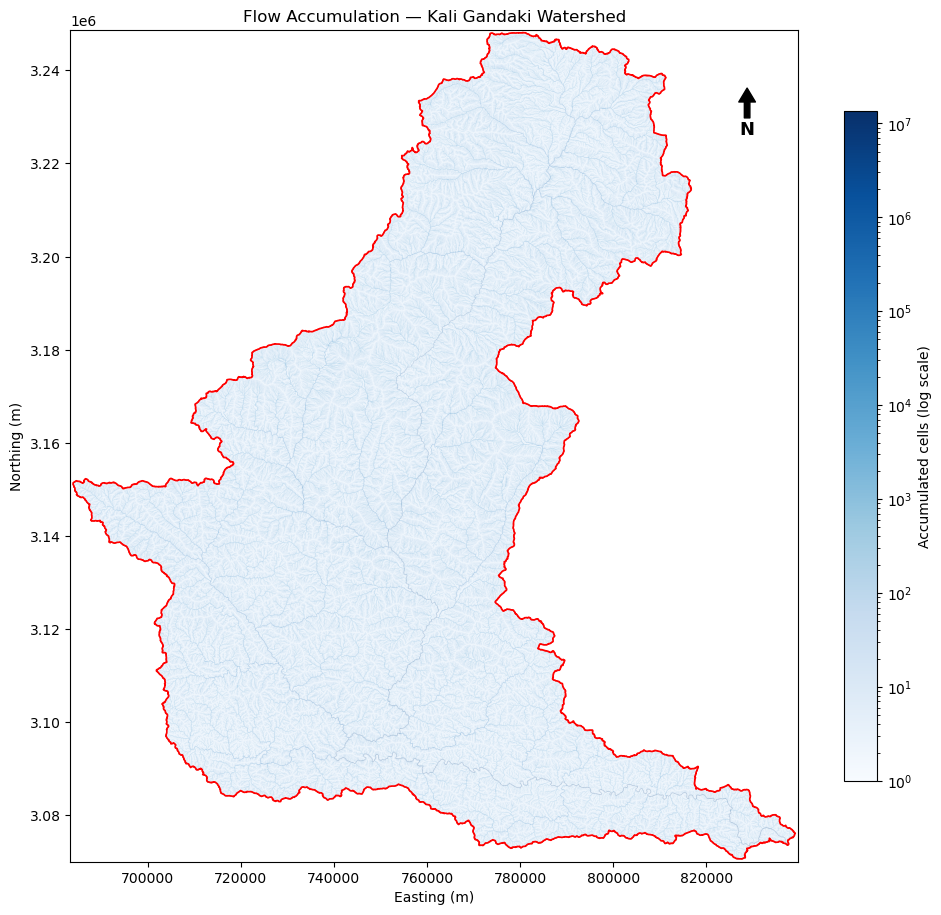

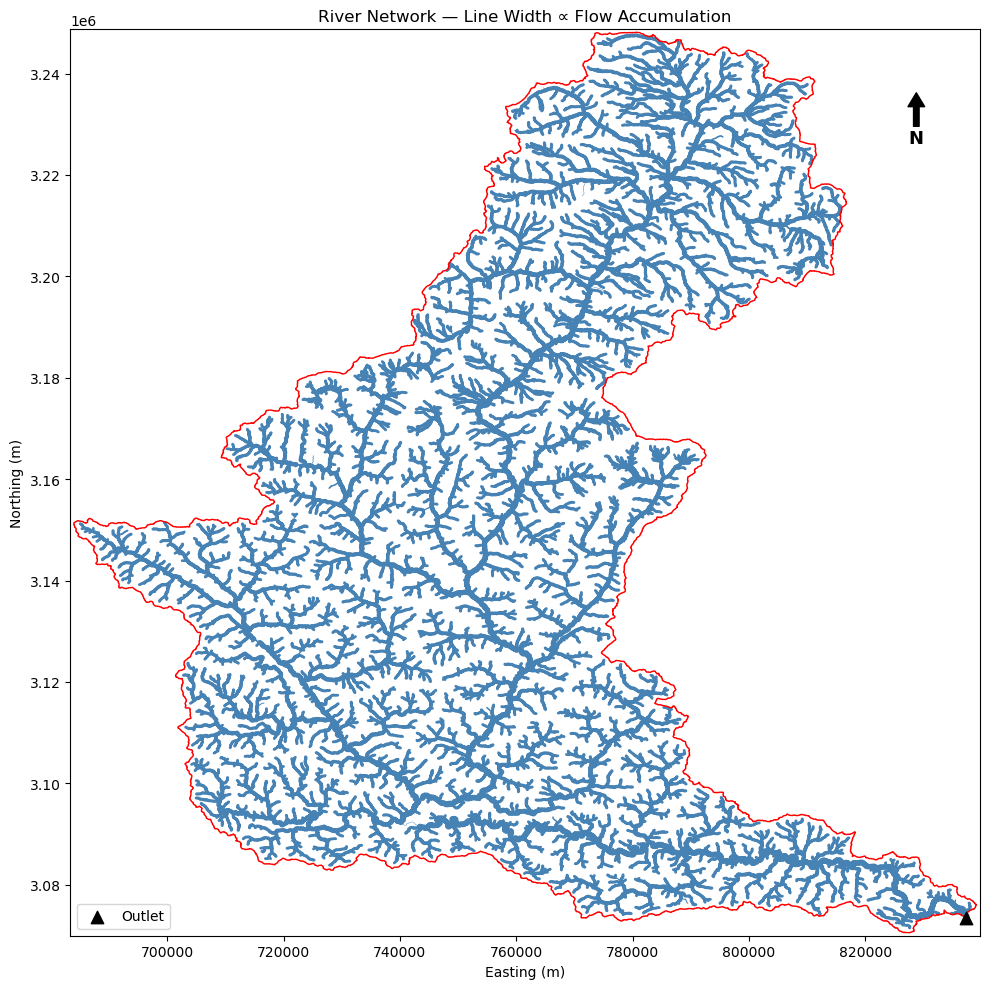

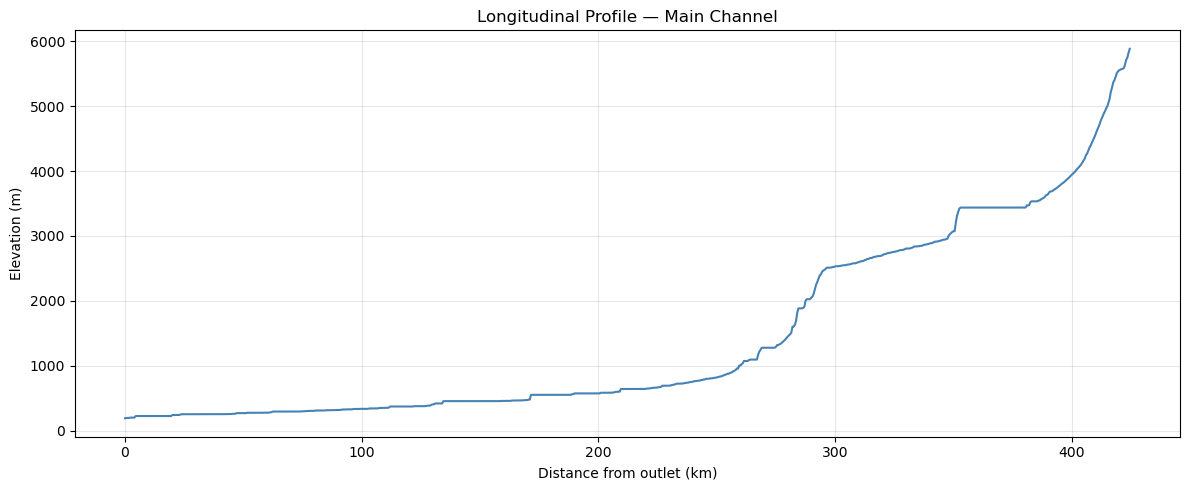

Main channel length: 424.7 km


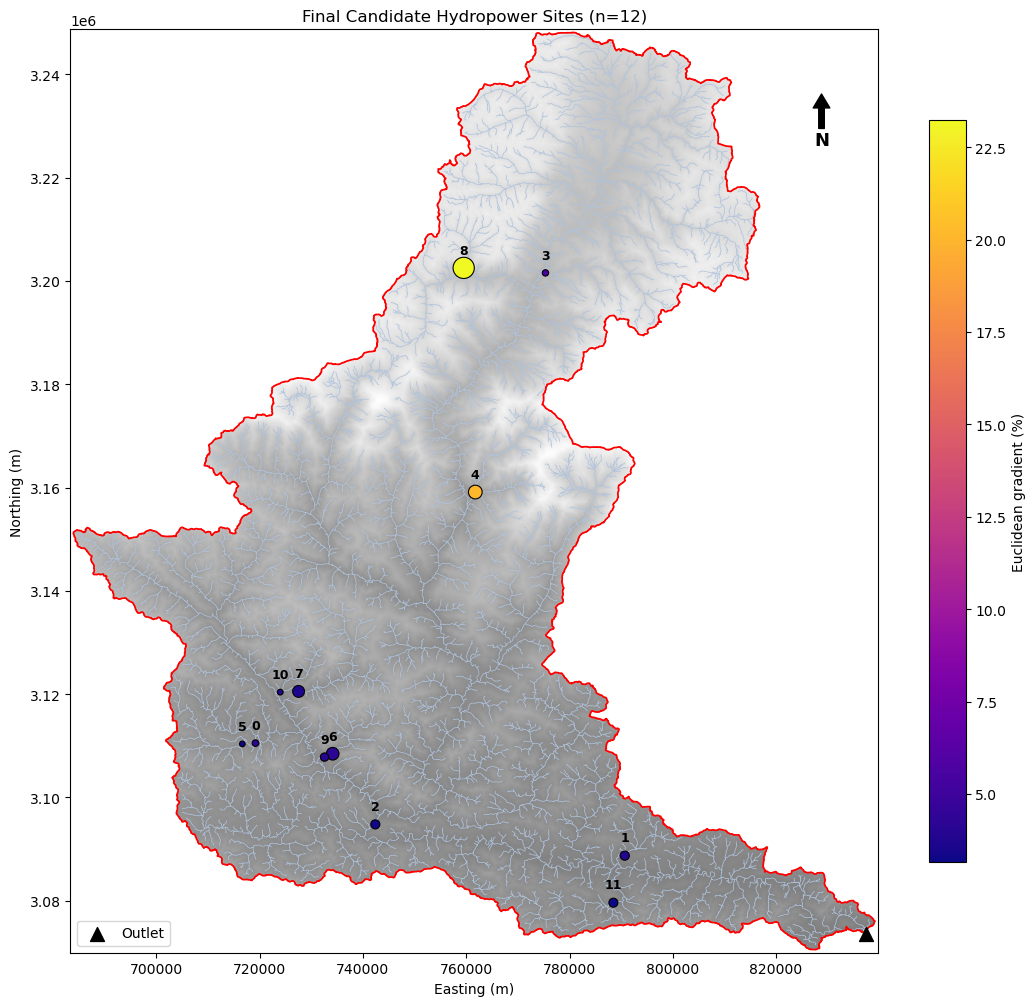

All 5 maps saved to results/figures/


In [19]:
# Cell 18: Final visualization suite — all 5 maps, clipped to watershed boundary, with north arrows.
# (a) DEM + watershed  (b) flow accumulation  (c) river network, width by discharge
# (d) longitudinal elevation profile of main channel  (e) final candidate sites, labeled

def add_north_arrow(ax, x=0.93, y=0.93, size=0.05):
    """Simple north arrow using axes-relative coordinates (top-right)."""
    ax.annotate("N", xy=(x, y), xytext=(x, y - size),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(facecolor="black", width=4, headwidth=12, headlength=10),
                ha="center", va="center", fontsize=13, fontweight="bold", zorder=10)

# --- (a) DEM + watershed ---
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(dem_masked, cmap="terrain", extent=[x_min, x_max, y_min, y_max])
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.5,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
cbar = plt.colorbar(im, ax=ax, shrink=0.7); cbar.set_label("Elevation (m)")
add_north_arrow(ax)
ax.set_title("DEM — Kali Gandaki Watershed")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map1_dem_watershed.png"), dpi=150); plt.show()

# --- (b) Flow accumulation ---
with rasterio.open(flow_accumulation) as src:
    facc_full2 = src.read(1)
facc_crop = facc_full2[row_min:row_max+1, col_min:col_max+1]
facc_masked = np.ma.masked_where(~valid_mask_crop | (facc_crop <= 0), facc_crop)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(facc_masked, cmap="Blues", norm=mcolors.LogNorm(), extent=[x_min, x_max, y_min, y_max])
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
cbar = plt.colorbar(im, ax=ax, shrink=0.7); cbar.set_label("Accumulated cells (log scale)")
add_north_arrow(ax)
ax.set_title("Flow Accumulation — Kali Gandaki Watershed")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map2_flow_accumulation.png"), dpi=150); plt.show()

# --- (c) River network, line width by discharge (flow accumulation at midpoint) ---
with rasterio.open(flow_accumulation) as src:
    facc_lookup = src.read(1)
    facc_transform2 = src.transform

def accum_at_point(x, y):
    r, c = rasterio.transform.rowcol(facc_transform2, x, y)
    try:
        return facc_lookup[r, c]
    except IndexError:
        return 0

mid_accum = [accum_at_point(*geom.interpolate(0.5, normalized=True).coords[0]) for geom in streams_gdf.geometry]
log_accum = np.log10(np.clip(mid_accum, 1, None))
norm_lw = (log_accum - log_accum.min()) / (log_accum.max() - log_accum.min())
linewidths_stream = 0.3 + norm_lw * 3.7

fig, ax = plt.subplots(figsize=(10, 10))
for geom, lw in zip(streams_gdf.geometry, linewidths_stream):
    xs, ys = geom.xy
    ax.plot(xs, ys, color="steelblue", linewidth=lw, solid_capstyle="round")
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.0,
           extent=[x_min, x_max, y_min, y_max], origin="upper")
ax.scatter([snap_x], [snap_y], color="black", marker="^", s=80, zorder=5, label="Outlet")
add_north_arrow(ax)
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.legend(loc="lower left")
ax.set_title("River Network — Line Width ∝ Flow Accumulation")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map3_river_network.png"), dpi=150); plt.show()

# --- (d) Longitudinal profile of main channel (outlet to farthest headwater) ---
farthest_node = max(node_cum_dist, key=node_cum_dist.get)
main_channel_path = nx.shortest_path(G, source=outlet_node, target=farthest_node, weight="length")
main_path_edges = {G.edges[main_channel_path[i], main_channel_path[i+1]]["fid"]
                    for i in range(len(main_channel_path)-1)}
main_profile_pts = river_points_gdf[river_points_gdf["edge_fid"].isin(main_path_edges)].sort_values("cum_dist_from_outlet_m")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(main_profile_pts["cum_dist_from_outlet_m"]/1000, main_profile_pts["elevation_m"], color="steelblue", lw=1.5)
ax.set_xlabel("Distance from outlet (km)"); ax.set_ylabel("Elevation (m)")
ax.set_title("Longitudinal Profile — Main Channel")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(str(figures_dir / "map4_longitudinal_profile.png"), dpi=150); plt.show()
print(f"Main channel length: {node_cum_dist[farthest_node]/1000:.1f} km")

# --- (e) Final candidate sites, labeled ---
fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(dem_masked, cmap="Greys_r", extent=[x_min, x_max, y_min, y_max], alpha=0.5)
for geom in streams_gdf.geometry:
    xs, ys = geom.xy
    ax.plot(xs, ys, color="lightsteelblue", linewidth=0.5, zorder=2)
ax.contour(valid_mask_crop.astype(int), levels=[0.5], colors="red", linewidths=1.2,
           extent=[x_min, x_max, y_min, y_max], origin="upper", zorder=3)

sc = ax.scatter(deduped_candidates["upstream_x"], deduped_candidates["upstream_y"],
                 c=deduped_candidates["euclidean_gradient_pct"], cmap="plasma",
                 s=deduped_candidates["delta_z_m"]/2, edgecolor="black", linewidth=0.8, zorder=5)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7); cbar.set_label("Euclidean gradient (%)")

for _, r in deduped_candidates.iterrows():
    ax.annotate(str(int(r["reach_id"])), (r["upstream_x"], r["upstream_y"]),
                textcoords="offset points", xytext=(0, 8), fontsize=9, fontweight="bold",
                ha="center", va="bottom")

ax.scatter([snap_x], [snap_y], color="black", marker="^", s=100, zorder=6, label="Outlet")
add_north_arrow(ax)
ax.legend(loc="lower left")
ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
ax.set_title(f"Final Candidate Hydropower Sites (n={len(deduped_candidates)})")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout(); plt.savefig(str(figures_dir / "map5_final_candidates.png"), dpi=200); plt.show()

print("All 5 maps saved to results/figures/")

In [22]:
# Cell 19: Interactive web map of watershed, river network, and candidate sites (Folium)
import folium
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
from shapely import set_precision
import geopandas as gpd
import pandas as pd
import os
from pathlib import Path

results_dir = Path("../results").resolve()

# --- Polygonize the watershed raster (currently only exists as a raster mask) ---
with rasterio.open(results_dir / "watershed.tif") as src:
    ws_arr = src.read(1)
    ws_transform = src.transform
    ws_valid = (ws_arr > 0) & (ws_arr != src.nodata)

ws_shapes = shapes(ws_valid.astype("uint8"), mask=ws_valid, transform=ws_transform)
ws_polygons = [shape(geom) for geom, val in ws_shapes if val == 1]
watershed_gdf = gpd.GeoDataFrame(geometry=ws_polygons, crs="EPSG:32644").to_crs("EPSG:4326")
watershed_dissolved = watershed_gdf.dissolve().geometry.iloc[0]

# --- Simplify + round precision on the watershed boundary ---
watershed_simplified = watershed_dissolved.simplify(tolerance=0.001, preserve_topology=True)
watershed_simplified = set_precision(watershed_simplified, grid_size=0.00001)

# --- Load river network, reproject, simplify, strip extra columns, round precision ---
streams_gdf = gpd.read_file(results_dir / "river_network.gpkg")
streams_wgs84 = streams_gdf.to_crs("EPSG:4326")
streams_wgs84_simplified = streams_wgs84.geometry.simplify(tolerance=0.002, preserve_topology=True)
streams_minimal = gpd.GeoDataFrame(geometry=streams_wgs84_simplified, crs="EPSG:4326")
streams_minimal["geometry"] = streams_minimal.geometry.apply(lambda g: set_precision(g, grid_size=0.00001))

# --- Load candidates, reproject ---
candidates_export = pd.read_csv(results_dir / "candidate_reaches.csv")
candidates_wgs84 = gpd.GeoDataFrame(
    candidates_export,
    geometry=gpd.points_from_xy(candidates_export["downstream_x"], candidates_export["downstream_y"]),
    crs="EPSG:32644"
).to_crs("EPSG:4326")

# --- Build the map ---
center = [candidates_wgs84.geometry.y.mean(), candidates_wgs84.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=9, tiles="OpenStreetMap")

folium.GeoJson(
    watershed_simplified.__geo_interface__,
    style_function=lambda x: {"color": "red", "weight": 2, "fillOpacity": 0.05},
    name="Watershed boundary"
).add_to(m)

folium.GeoJson(
    streams_minimal.__geo_interface__,
    style_function=lambda x: {"color": "steelblue", "weight": 1.5, "opacity": 0.6},
    name="River network"
).add_to(m)

for _, row in candidates_wgs84.iterrows():
    popup_html = (
        f"<b>Site {int(row['reach_id'])}</b><br>"
        f"ΔZ: {row['delta_z_m']:.1f} m<br>"
        f"River distance: {row['river_distance_m']:.0f} m<br>"
        f"Euclidean distance: {row['euclidean_distance_m']:.0f} m<br>"
        f"Route-length ratio: {row['route_length_ratio']:.2f}<br>"
        f"Euclidean gradient: {row['euclidean_gradient_pct']:.1f}%<br>"
        f"Contributing area: {row['contrib_area_km2']:.1f} km²"
    )
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=7, color="black", weight=1, fill=True,
        fill_color="orange", fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"Site {int(row['reach_id'])}"
    ).add_to(m)

folium.LayerControl().add_to(m)

map_path = str((results_dir / "candidate_sites_map.html").resolve())
m.save(map_path)

size_mb = os.path.getsize(map_path) / (1024 * 1024)
print("Interactive map saved to:", map_path)
print(f"File size: {size_mb:.2f} MB")

Interactive map saved to: D:\kaligandaki\results\candidate_sites_map.html
File size: 1.28 MB
